In [1]:
import pandas as pd
import json

In [3]:
with open('TelecomX_Data.json') as f:
    data = json.load(f)

In [4]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [6]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
df = df[df['Churn'] != ""]

In [9]:
df.columns = df.columns.str.replace('.', '_')

In [10]:
df['daily_charge'] = df['account_Charges_Monthly'] / 30

In [11]:
df['Churn_binary'] = df['Churn'].map({'Yes':1, 'No':0})

In [13]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [14]:
pd.crosstab(df['account_Contract'], df['Churn'], normalize='index')

Churn,No,Yes
account_Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [15]:
pd.crosstab(df['internet_InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
internet_InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [16]:
pd.crosstab(df['account_PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
account_PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [17]:
df.groupby('Churn')['customer_tenure'].mean()

,customer_tenure
Churn,
No,37.569965
Yes,17.979133


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

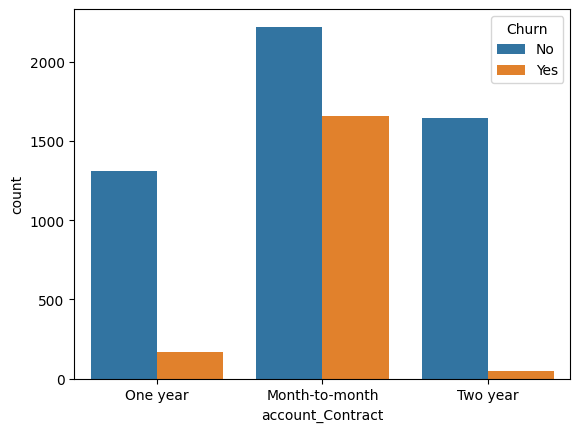

In [19]:
sns.countplot(data=df, x='account_Contract', hue='Churn')
plt.show()

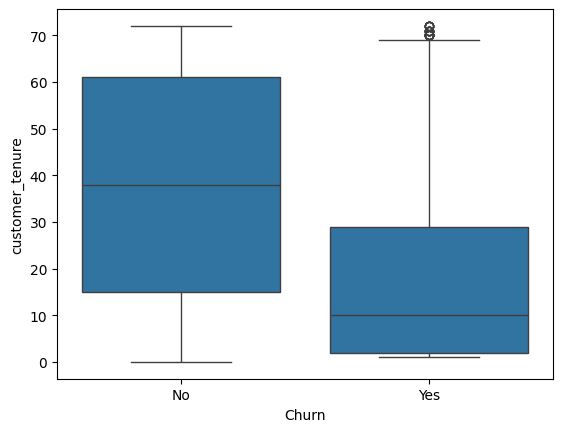

In [20]:
sns.boxplot(data=df, x='Churn', y='customer_tenure')
plt.show()

In [22]:
#Conclusiones del análisis
#El análisis exploratorio de los datos muestra varios factores asociados con la evasión de clientes (churn):
#Tipo de contrato
#Los clientes con contratos month-to-month presentan una tasa de abandono significativamente mayor en comparación con los clientes con contratos de uno o dos años. Esto sugiere que los contratos más largos ayudan a retener clientes.
#Antigüedad del cliente (tenure)
#Los clientes que abandonan la empresa suelen tener pocos meses de permanencia, lo que indica que los primeros meses del servicio son críticos para la retención.
#Tipo de servicio de internet
#Los usuarios con Fiber Optic presentan mayor churn, lo que podría estar relacionado con precios más altos o expectativas de servicio no satisfechas.
#Método de pago
#Los clientes que utilizan Electronic Check presentan mayor tasa de abandono, lo cual podría indicar menor compromiso o posibles fricciones en el proceso de pago.
#Costo del servicio
#En general, los clientes que abandonan tienden a tener cargos mensuales más altos, lo que podría influir en la decisión de cancelar el servicio.
#Recomendaciones
#Incentivar contratos de mayor duración.
#Mejorar la experiencia del cliente en los primeros meses del servicio.
#Analizar posibles problemas de calidad o precio en el servicio Fiber Optic.
#Revisar estrategias de fidelización para clientes con pagos por Electronic Check.